# Objective 3: Predicting erosion from storm characteristics

This notebook tests whether storm conditions can predict coastal erosion.

We use the monthly master dataset that already includes:
- storm metrics (buoy + model)
- assigned storm types (from clustering)
- shoreline response and erosion flag

We build simple, interpretable prediction models:
1) Classification: predict whether a month is an erosion month (True/False)
2) Regression (optional): predict the magnitude of shoreline change


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

# -----------------------------
# Paths 
# -----------------------------
PROJECT_DIR = Path(r"C:\Users\anura\Downloads\DATA601-PROJECT")
RESULTS_DIR = PROJECT_DIR / "results"
TABLE_DIR   = RESULTS_DIR / "tables"
FIG_DIR     = RESULTS_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("TABLE_DIR:", TABLE_DIR)
print("FIG_DIR  :", FIG_DIR)


TABLE_DIR: C:\Users\anura\Downloads\DATA601-PROJECT\results\tables
FIG_DIR  : C:\Users\anura\Downloads\DATA601-PROJECT\results\figures


## Load dataset

We load the dataset that already includes `storm_type`.
This is required for Objective 3 because storm type is one of our key predictors.


In [2]:
df = pd.read_csv(
    TABLE_DIR / "master_with_storm_types.csv",
    parse_dates=["month"]
)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())
display(df.head())


Rows: 314
Columns: ['month', 'mean_shoreline_change', 'ecan_storm_hours', 'ecan_max_Hs', 'ecan_mean_Hs', 'ecan_mean_dir', 'model_storm_hours', 'model_max_Hs', 'model_mean_Hs', 'model_mean_dir', 'erosion_month', 'storm_type']


,month,mean_shoreline_change,ecan_storm_hours,ecan_max_Hs,ecan_mean_Hs,ecan_mean_dir,model_storm_hours,model_max_Hs,model_mean_Hs,model_mean_dir,erosion_month,storm_type
0,1999-01-07,NaN,10.0,3.22,2.694000,150.844000,20.0,6.1611,4.835027,148.519700,False,1
1,1999-01-08,2.105517,7.0,3.60,3.117143,177.682857,2.0,4.4776,4.375580,195.086000,False,2
2,1999-01-09,3.266016,2.0,3.62,3.160000,161.105000,7.0,4.5849,4.377566,197.312429,False,2
3,1999-01-10,3.780714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1
4,1999-01-11,1.193659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1


## Target variable: erosion_month

`erosion_month` indicates whether the shoreline retreated overall that month.
We confirm the format (True/False) and class balance.


In [3]:
if "erosion_month" not in df.columns:
    raise ValueError("erosion_month column not found in master_with_storm_types.csv")

print("erosion_month counts:")
display(df["erosion_month"].value_counts(dropna=False))

# Convert to numeric 0/1 target for modelling
y = df["erosion_month"].astype("boolean")


erosion_month counts:


erosion_month
False    163
True     151
Name: count, dtype: int64

## Build predictors (X) and target (y)

We use two sets of predictors:
1) Storm physics (buoy-based): intensity, duration, direction
2) Storm type (categorical) from clustering

We drop rows missing required predictors or target.


In [4]:
# Choose predictors (buoy-based is best for explaining erosion)
num_cols = ["ecan_mean_Hs", "ecan_max_Hs", "ecan_storm_hours", "ecan_mean_dir"]
cat_cols = ["storm_type"]

missing = [c for c in num_cols + cat_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

model_df = df.dropna(subset=num_cols + cat_cols + ["erosion_month"]).copy()

print("Rows available for modelling:", len(model_df))
display(model_df[["month", "storm_type", "erosion_month"] + num_cols].head())

# Target as 0/1
y = model_df["erosion_month"].astype(int)


Rows available for modelling: 300


,month,storm_type,erosion_month,ecan_mean_Hs,ecan_max_Hs,ecan_storm_hours,ecan_mean_dir
0,1999-01-07,1,False,2.694000,3.22,10.0,150.844000
1,1999-01-08,2,False,3.117143,3.60,7.0,177.682857
2,1999-01-09,2,False,3.160000,3.62,2.0,161.105000
12,2000-01-07,0,True,2.575000,2.66,4.0,82.712500
13,2000-01-08,2,True,2.761111,3.26,9.0,148.842222


## Direction is circular (0° = 360°)

Wave direction cannot be treated like a normal number because 1° and 359° are actually close.
To handle this correctly, we convert direction into:
- sin(direction)
- cos(direction)

These capture circular patterns properly and improve model stability.


In [5]:
dir_rad = np.deg2rad(model_df["ecan_mean_dir"])
model_df["dir_sin"] = np.sin(dir_rad)
model_df["dir_cos"] = np.cos(dir_rad)

# Replace raw direction with sin/cos in numeric predictors
num_cols_fixed = ["ecan_mean_Hs", "ecan_max_Hs", "ecan_storm_hours", "dir_sin", "dir_cos"]


## Encode storm_type (categorical predictor)

Storm type is categorical, so we convert it into dummy variables.
This allows logistic regression to use storm type as a predictor.


In [6]:
X_num = model_df[num_cols_fixed].copy()
X_cat = pd.get_dummies(model_df["storm_type"], prefix="type", drop_first=False)

X = pd.concat([X_num, X_cat], axis=1)

print("Predictor matrix shape:", X.shape)
print("Erosion months (1s):", y.sum(), "/", len(y))
display(X.head())


Predictor matrix shape: (300, 8)
Erosion months (1s): 146 / 300


,ecan_mean_Hs,ecan_max_Hs,ecan_storm_hours,dir_sin,dir_cos,type_0,type_1,type_2
0,2.694000,3.22,10.0,0.487189,-0.873296,False,True,False
1,3.117143,3.60,7.0,0.040431,-0.999182,False,False,True
2,3.160000,3.62,2.0,0.323835,-0.946114,False,False,True
12,2.575000,2.66,4.0,0.991922,0.126848,True,False,False
13,2.761111,3.26,9.0,0.517397,-0.855746,False,False,True


## Train-test split

We split the data into training (70%) and test (30%).
We stratify by erosion_month to preserve the erosion / non-erosion balance.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train), "Test:", len(X_test))


Train: 210 Test: 90


## Logistic regression (classification)

We fit a logistic regression model to predict the probability of an erosion month.

We use a pipeline with:
- median imputation (for safety)
- scaling (important for logistic regression)
- logistic regression classifier


In [8]:
clf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000))
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]


## Classification performance

We evaluate:
- confusion matrix
- precision/recall/F1
- ROC-AUC


In [9]:
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", round(auc, 3))


Confusion matrix:
[[31 15]
 [25 19]]

Classification report:
              precision    recall  f1-score   support

           0       0.55      0.67      0.61        46
           1       0.56      0.43      0.49        44

    accuracy                           0.56        90
   macro avg       0.56      0.55      0.55        90
weighted avg       0.56      0.56      0.55        90

ROC-AUC: 0.562


## ROC Curve

The ROC curve visualises the tradeoff between:
- detecting erosion months (true positives)
- false alarms (false positives)


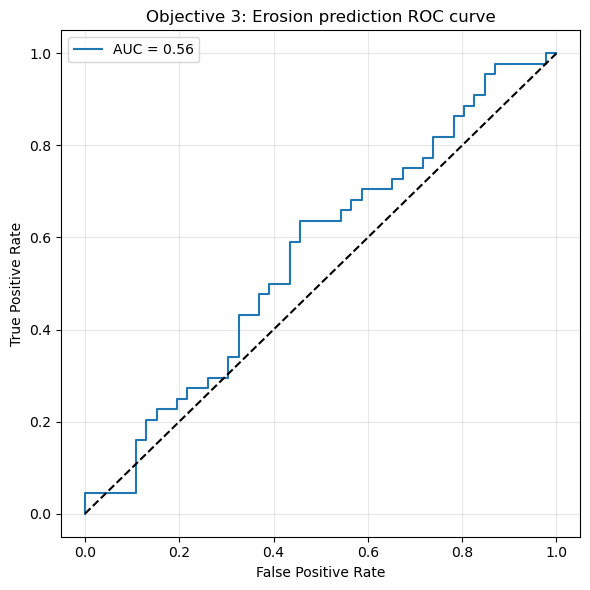

Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\figures\fig_obj3_erosion_prediction_ROC.png


In [10]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Objective 3: Erosion prediction ROC curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

outpath = FIG_DIR / "fig_obj3_erosion_prediction_ROC.png"
plt.savefig(outpath, dpi=200)
plt.show()

print("Saved:", outpath)


## Interpretability: logistic regression coefficients

We extract the logistic regression coefficients to see which predictors increase erosion probability.
Positive coefficient → higher erosion risk.
Negative coefficient → lower erosion risk.


In [11]:
# Extract coefficients from pipeline
coef = clf.named_steps["logreg"].coef_[0]
coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coef
}).sort_values("coefficient")

display(coef_table)

outpath = TABLE_DIR / "table_obj3_logistic_coefficients.csv"
coef_table.to_csv(outpath, index=False)
print("Saved:", outpath)


,feature,coefficient
1,ecan_max_Hs,-0.720460
3,dir_sin,-0.370227
5,type_0,-0.048536
7,type_2,-0.033069
6,type_1,0.062602
4,dir_cos,0.287358
0,ecan_mean_Hs,0.645871
2,ecan_storm_hours,0.912758


Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\tables\table_obj3_logistic_coefficients.csv


## Optional regression: predicting shoreline change magnitude

Some months may not have a valid numeric value for `mean_shoreline_change`
(e.g., missing shoreline observations or QC filtering).

Before fitting a regression model, we must remove rows where the regression target is NaN.


In [12]:
# Optional regression only if the column exists
if "mean_shoreline_change" in model_df.columns:

    # Drop rows where the regression target is missing
    reg_df = model_df.dropna(subset=["mean_shoreline_change"]).copy()

    # Target variable
    y_reg = reg_df["mean_shoreline_change"].astype(float)

    # IMPORTANT: use predictors aligned to reg_df rows
    X_num_reg = reg_df[num_cols_fixed].copy()
    X_cat_reg = pd.get_dummies(reg_df["storm_type"], prefix="type", drop_first=False)
    X_reg = pd.concat([X_num_reg, X_cat_reg], axis=1)

    print("Rows available for regression:", len(reg_df))
    print("Target range:", y_reg.min(), "to", y_reg.max())

    # Train/test split
    Xr_train, Xr_test, yr_train, yr_test = train_test_split(
        X_reg, y_reg, test_size=0.30, random_state=42
    )

    # Regression pipeline
    reg = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression())
    ])

    # Fit + predict
    reg.fit(Xr_train, yr_train)
    pred = reg.predict(Xr_test)

    # Metrics
    mae = mean_absolute_error(yr_test, pred)
    rmse = np.sqrt(mean_squared_error(yr_test, pred))
    r2 = r2_score(yr_test, pred)

    print("\nRegression performance:")
    print("MAE :", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R²  :", round(r2, 3))

    # Save metrics table
    reg_summary = pd.DataFrame([{"MAE": mae, "RMSE": rmse, "R2": r2, "n_rows": len(reg_df)}])
    outpath = TABLE_DIR / "table_obj3_regression_skill.csv"
    reg_summary.to_csv(outpath, index=False)
    print("Saved:", outpath)

else:
    print("mean_shoreline_change column not found — skipping regression.")


Rows available for regression: 299
Target range: -6.091395184135977 to 5.756565333333334

Regression performance:
MAE : 1.04
RMSE: 1.442
R²  : 0.056
Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\tables\table_obj3_regression_skill.csv


Figure saved: correlation_matrix_storm_shoreline.png


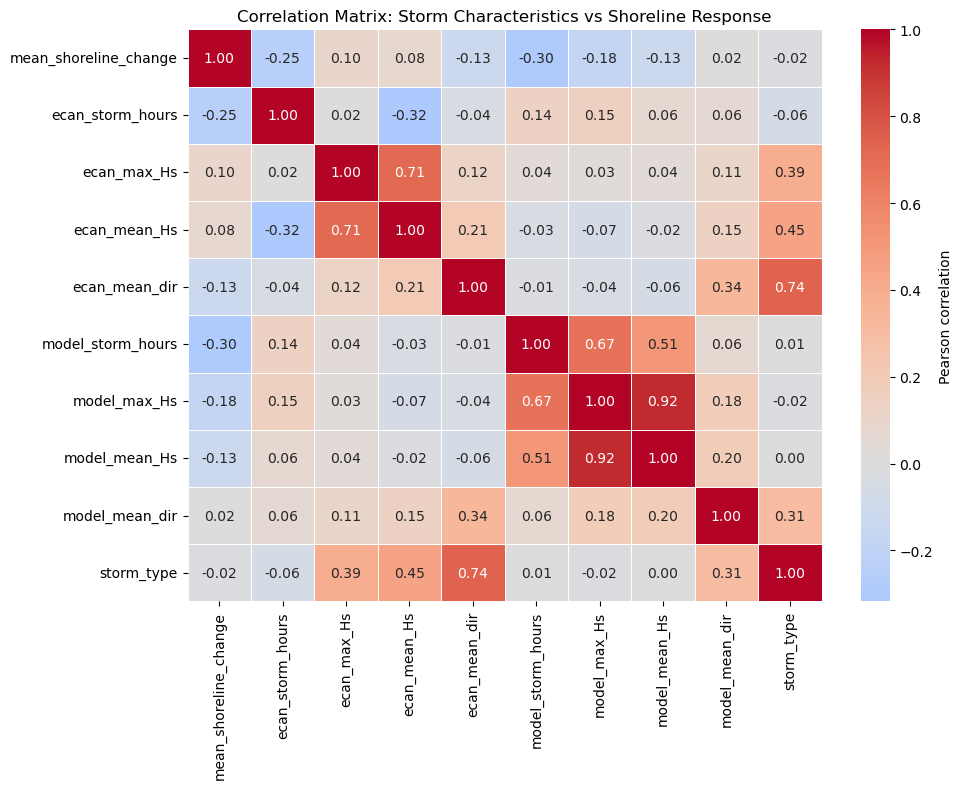

In [22]:
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"}
)

ax.set_title("Correlation Matrix: Storm Characteristics vs Shoreline Response")
plt.tight_layout()

outpath = FIG_DIR / "correlation_matrix_storm_shoreline.png"
plt.savefig(
    outpath,
    dpi=300,
    bbox_inches="tight"
)

ax.set_title("Correlation Matrix: Storm Characteristics vs Shoreline Response")
plt.tight_layout()

print("Figure saved: correlation_matrix_storm_shoreline.png")